In [2]:
# generate some linear looking data to test the normal equation
import numpy as np
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

In [3]:
# Take a look at the data 
print(f"X data generated: {X[:5]} \n")
print(f"Y data generated: {y[:5]}")

X data generated: [[1.96884673]
 [1.4655125 ]
 [0.24199951]
 [1.05505151]
 [0.17346957]] 

Y data generated: [[9.7398537 ]
 [8.76332131]
 [5.00801156]
 [7.31539679]
 [4.6994937 ]]


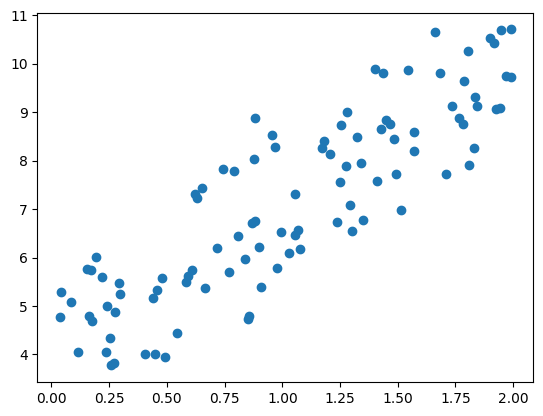

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [5]:
# calculate the hypothesis parameter 
X_b = np.c_[np.ones((100,1)),X] # add x0 =1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(theta_best)

[[4.17990293]
 [2.85931688]]


The actual parameters are 4 and 3, we got 4.22 and 2.87 due to the Gaussian noises we added

In [6]:
# make predictions using theta 
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]# add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
print(y_predict)

[[4.17990293]
 [9.8985367 ]]


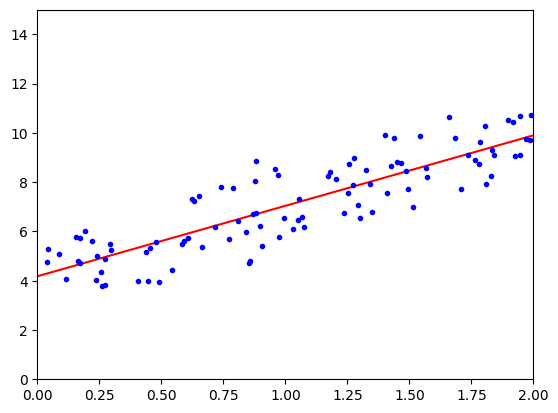

In [7]:
# plot the model's predictions
plt.plot(X_new, y_predict, "r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

In [8]:
# perform linear regression 
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(lin_reg.intercept_)
print(lin_reg.coef_)
print(lin_reg.predict(X_new))



[4.17990293]
[[2.85931688]]
[[4.17990293]
 [9.8985367 ]]


In [9]:
# use the least squares function instead
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.17990293],
       [2.85931688]])

In [10]:
np.linalg.pinv(X_b).dot(y)

array([[4.17990293],
       [2.85931688]])

In [11]:
# implement batch gradient descent
eta = 0.1 # learning rate 
n_iterations = 1000
m = 100

theta = np.random.randn(2,1) # random initialisation

for iteration in range(n_iterations):
  gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
  theta = theta - eta * gradients

print(theta)

[[4.17990293]
 [2.85931688]]


In [12]:
# implementing stochastic gradient descent 
n_epochs = 50
t0, t1 = 5,50 # learning schedule hyperparameters 

def learning_schedule(t):
  return t0 / (t + t1)

theta = np.random.randn(2,1) # random initialisation

for epoch in range(n_epochs):
  for i in range(m):
    random_index = np.random.randint(m)
    xi =X_b[random_index: random_index+1]
    yi =y[random_index: random_index+1]
    gradients = 2*xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch*m + i)
    theta = theta - eta * gradients

print(theta)

[[4.14110158]
 [2.83135685]]


To ensure the parameters are getting pulled towards the global optimum, we can shuffle the instances during training

In [13]:
# perform linear regression using SGD with sklearn
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter = 1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X,y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([4.15214085]), array([2.84728356]))

Polynomial Regression 
Using a linear model to fit nonlinear data

In [14]:
# generate nonlinear data 
m = 100
X = 6 * np.random.rand(m, 1) -3 # add noise
y = 0.5 * X**2 + X +2 + np.random.randn(m,1) # quadratic eqn and added noise


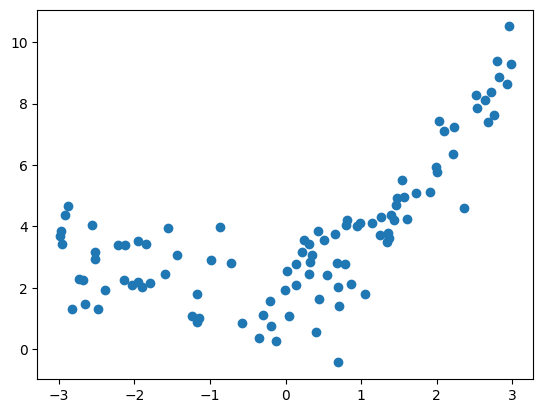

In [15]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [16]:
# use sklearn's polynomial class to transform the training data
# adding the square of each feature in the training set as new features
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree = 2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0], X_poly[0])

[2.80409554] [2.80409554 7.86295182]


In [17]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

[2.04418521] [[0.91677392 0.50205623]]


In [18]:
X_plot = np.linspace(-3,3,100).reshape(100,1)
X_plot_poly = poly_features.transform(X_plot)
y_plot = lin_reg.predict(X_plot_poly)

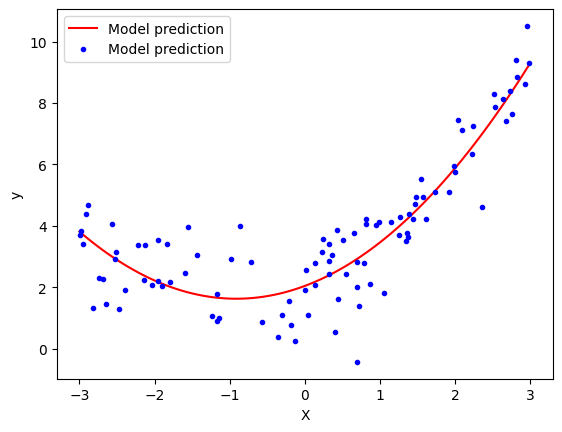

In [19]:
# plot the model's predictions
plt.plot(X_plot,y_plot, "r-", label="Model prediction")
plt.plot(X,y,"b.", label="Model prediction")
plt.xlabel("X")
plt.ylabel("y")

plt.legend()
plt.show()

Learning curves

In [20]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, x, y):
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
  train_errors, val_errors = [], []

  for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_predict = model.predict(X_train[:m])
    y_val_predict = model.predict(X_val)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))
  
  plt.plot(np.sqrt(train_errors),"r-+", linewidth=2, label="train")
  plt.plot(np.sqrt(val_errors),"b-", linewidth=3, label="val")

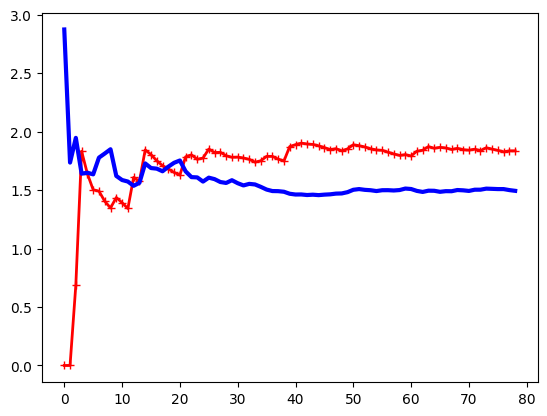

In [21]:
# plot the learning curves of the plain linear regression model 
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

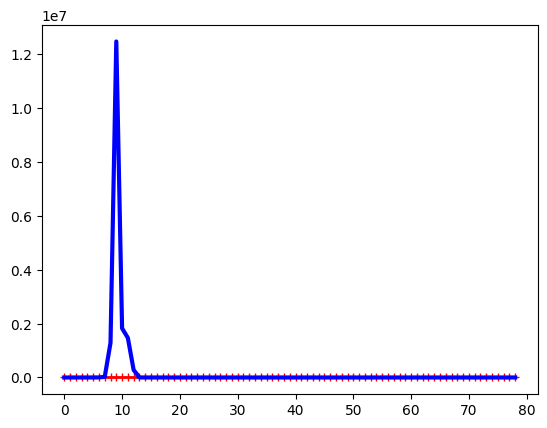

In [22]:
# plot the learning curves of a 10th degree polynomial model on the same data
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
  ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
  ("lin_reg", LinearRegression()),
])

plot_learning_curves(polynomial_regression, X, y)

In [23]:
# perform ridge regression using closed-form soltion
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver = "cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([4.86538636])

In [24]:
# use stochastic gradient descent 
sgd_reg = SGDRegressor(penalty='l2')
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.83752182])

In [25]:
# implement lasso regression
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X,y)
lasso_reg.predict([[1.5]])

array([4.82474479])

In [26]:
# implement elastic net
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha = 0.1, l1_ratio=0.5) #half n half
elastic_net.fit(X,y)
elastic_net.predict([[1.5]])

array([4.82923735])

In [27]:
# implement early stopping
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

#prepare the data
poly_scaler = Pipeline([
  ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
  ("std_scalar", StandardScaler())
])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sdg_reg = SGDRegressor(max_iter=1, tol= -np.inf, warm_start = True, 
                       penalty=None, learning_rate="constant", eta0 = 0.0005
                       )

minimum_val_error = float("inf")
best_epoch = None
best_model = None

for epoch in range(1000):
  sgd_reg.fit(X_train_poly_scaled, y_train.ravel()) # continues where it left off
  y_val_predict = sgd_reg.predict(X_val_poly_scaled)
  val_error = mean_squared_error(y_val.ravel(), y_val_predict)
  
  if val_error < minimum_val_error:
    minimum_val_error = val_error
    best_epoch = epoch
    best_model = clone(sgd_reg)

Build a classifier using logistic regression

In [28]:
# load the data 
from sklearn import datasets
iris = datasets.load_iris()
print(list(iris.keys()))

['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


In [30]:
X = iris["data"][:, 3:] # petal width 
y = (iris["target"]== 2).astype(int) # 1 if Iris-Virginica, else 0 


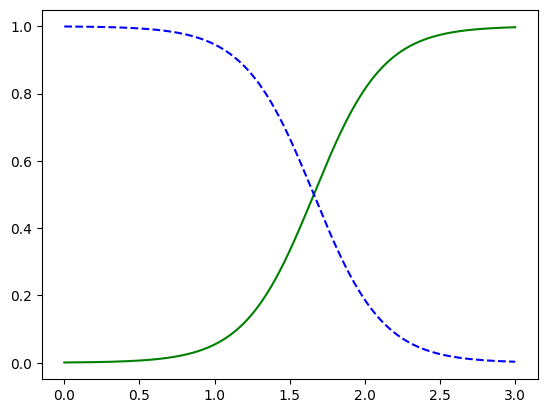

In [33]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X,y)

# estimated probabilities for flowers with petal widths varying from 0-3cm
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:,1],"g-", label= "Iris-Virginica")
plt.plot(X_new, y_proba[:,0], "b--",label="Not Iris-Virginica")

In [35]:
log_reg.predict([[1.7],[1.5]]) # the decision boundary is around 1.6

array([1, 0])

In [37]:
X = iris["data"][:,(2,3)] # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression( solver="lbfgs",C=10)
softmax_reg.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
print(softmax_reg.predict([[5,2]]))
print(softmax_reg.predict_proba([[5,2]]))


[2]
[[6.21626370e-07 5.73689802e-02 9.42630398e-01]]
